# The α-Function Zoo — Milestone 7.2 (v0.4.0)

Every cubic equation of state in this library shares the same Abbott skeleton; what distinguishes Peng-Robinson from Soave-RK from a polar Mathias-Naumann variant is a single scalar function — **α(T_r)**, the temperature dependence of the attractive term. Milestone 7.1 shipped the four α functions the Chapter IV validation cases need; **Milestone 7.2 ports the twelve remaining two-parameter variants** from the VB6 legacy, each with an analytical dα/dT_r. This notebook is the guided tour of the whole two-parameter zoo.

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context — Chapter II §2.3 (cubic EOS) and the role of α(T_r)

From [Chapter II §2.3](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md): every cubic EOS in this library is written in the **Abbott form**

$$P = \frac{R T}{V - b} - \frac{a \, \alpha(T_r)}{V^2 + k_1 b V + k_2 b^2}.$$

The family constants `(k_1, k_2, Ω_a, Ω_b)` fix the *shape* of the EOS (VdW / RKS / PR families); **α(T_r) carries all the temperature dependence of the attractive term**. A good α must satisfy α(T_r = 1) = 1 (the attractive term equals its critical-point value at T_c) and decrease monotonically-ish with T_r. The dozens of published α functions trade off accuracy near the critical point, in the sub-critical liquid, and for polar molecules.

The VB6 program (`legacy/vb6/clsQbicsPure.cls:1719`, `Friend Function Alpha`) carries **nineteen** α variants. M7.1 ported the four the validation cases use; M7.2 ports twelve more. The three OL-family variants (VdWOL1998 / RKOL1998 / PROL1998) are *not* pure functions of T_r — their α reads the component's reduced saturation pressure — so they are deferred to **M7.4** alongside the saturation layer they depend on (see [`02d_advanced_saturation.ipynb`](02d_advanced_saturation.ipynb)).

## What was built in Milestone 7.2

Twelve new α(T_r) branches in [`engine/src/eos.rs`](https://github.com/miguelju/vle/blob/main/engine/src/eos.rs), each with a hand-derived analytical dα/dT_r and a central-difference oracle test:

| Variant | Family | α(T_r) shape | Extra parameter(s) |
|---|---|---|---|
| `Berth1899` | VdW | 1 / T_r | — |
| `VdWAda1984` | VdW | 10^(m(ω)·(1 − T_r)) | — |
| `RKSGD1978` | RKS | [1 + m(ω)(1 − √T_r)]² | — |
| `RKSL1997` | RKS | [1 + m(ω)(1 − √T_r)]² | — |
| `RP1978` | PR | [1 + m(ω)(1 − √T_r)]² | — |
| `PRL1997` | PR | [1 + m(ω)(1 − √T_r)]² | — |
| `VdWVald1989` | RKS | 1 + (1 − T_r)(m + n/T_r) | reads Z_c |
| `RKSmn1980` | RKS | 1 + (1 − T_r)(m + n/T_r) | fitted m, n |
| `RKSATmn1995` | RKS | exp[(1−T_r)m\|1−T_r\|^(g−1) + n(1/T_r−1)] | fitted m, n, g |
| `PRATmng1997` | PR | exp[(1−T_r)m\|1−T_r\|^(g−1) + n(1/T_r−1)] | fitted m, n, g |
| `PRMmn1989` | PR | exp[(1−T_r)m + n(1−√T_r)²] | fitted m, n |
| `PRSV1986` | PR | [1 + κ(1−√T_r)]², κ = κ₀(ω) + K₁(1+√T_r)(0.7−T_r) | fitted K₁ |

The variants that read only ω are reachable through the original `eos_alpha(eos, T_r, ω)` binding. The variants that read a fitted parameter (Z_c, m, n, g, K₁) use the **new `eos_alpha_ex(eos, T_r, ω, zc=…, m=…, n=…, g=…, prsv_k1=…)`** binding (and `eos_d_alpha_d_tr_ex(...)` for its derivative). `eos_alpha_ex` is a strict superset — with the defaults it reproduces `eos_alpha` exactly.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vle._engine import (
    CubicEos,
    eos_alpha,
    eos_alpha_ex,
    eos_d_alpha_d_tr,
    eos_d_alpha_d_tr_ex,
    version,
)

print(f'vle._engine version: {version()}')

vle._engine version: 0.4.0


## 1. The acentric-factor-only α functions, side by side

Six of the twelve new variants depend only on ω, so they plot directly against `eos_alpha`. Together with the four M7.1 core variants that is the full **ten-curve** ω-only family. They all pass through (T_r = 1, α = 1) — the critical-point constraint — and fan out below T_c. n-pentane (ω = 0.252) is the test fluid.

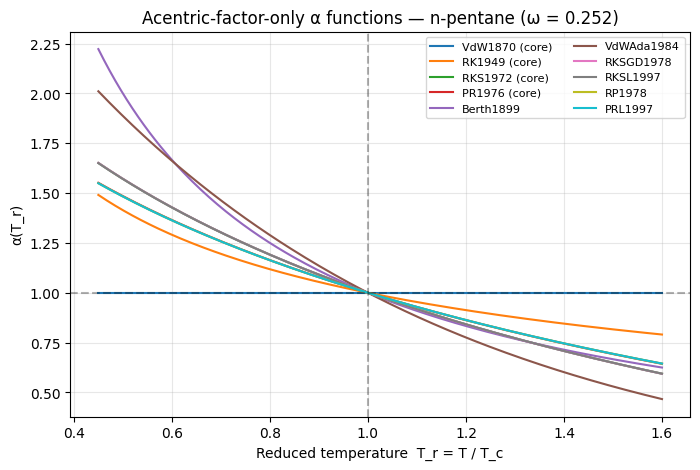

In [3]:
OMEGA = 0.252  # n-pentane
trs = np.linspace(0.45, 1.6, 200)

omega_only = [
    (CubicEos.VdW1870,   'VdW1870 (core)'),
    (CubicEos.RK1949,    'RK1949 (core)'),
    (CubicEos.RKS1972,   'RKS1972 (core)'),
    (CubicEos.PR1976,    'PR1976 (core)'),
    (CubicEos.Berth1899, 'Berth1899'),
    (CubicEos.VdWAda1984,'VdWAda1984'),
    (CubicEos.RKSGD1978, 'RKSGD1978'),
    (CubicEos.RKSL1997,  'RKSL1997'),
    (CubicEos.RP1978,    'RP1978'),
    (CubicEos.PRL1997,   'PRL1997'),
]

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.get_cmap('tab10')
for i, (eos, label) in enumerate(omega_only):
    alphas = [eos_alpha(eos, float(tr), OMEGA) for tr in trs]
    ax.plot(trs, alphas, label=label, color=cmap(i % 10))

ax.axvline(1.0, color='k', alpha=0.3, ls='--')
ax.axhline(1.0, color='k', alpha=0.3, ls='--')
ax.set_xlabel('Reduced temperature  T_r = T / T_c')
ax.set_ylabel('α(T_r)')
ax.set_title('Acentric-factor-only α functions — n-pentane (ω = 0.252)')
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.show()

Every curve hits α = 1 at T_r = 1 by construction — let's assert that for **all twelve** new variants plus the four core ones, so a future regression in any branch fails this notebook.

In [4]:
# A synthetic polar component carrying every fitted parameter the
# parameterized variants read. g > 1 keeps |1−Tr|^(g−1) smooth at Tr=1.
POLAR = dict(omega=0.344, zc=0.229, m=0.45, n=0.12, g=1.5, prsv_k1=0.07)

ALL_TWO_PARAM = [
    CubicEos.VdW1870, CubicEos.RK1949, CubicEos.RKS1972, CubicEos.PR1976,
    CubicEos.Berth1899, CubicEos.VdWAda1984, CubicEos.RKSGD1978,
    CubicEos.RKSL1997, CubicEos.RP1978, CubicEos.PRL1997,
    CubicEos.VdWVald1989, CubicEos.RKSmn1980, CubicEos.RKSATmn1995,
    CubicEos.PRATmng1997, CubicEos.PRMmn1989, CubicEos.PRSV1986,
]
for eos in ALL_TWO_PARAM:
    a1 = eos_alpha_ex(eos, 1.0, **POLAR)
    assert abs(a1 - 1.0) < 1e-12, f'{eos}: α(Tr=1)={a1}'
print(f'α(Tr=1) = 1 verified for all {len(ALL_TWO_PARAM)} two-parameter variants ✓')

α(Tr=1) = 1 verified for all 16 two-parameter variants ✓


## 2. The parameterized variants via `eos_alpha_ex`

Six variants read a fitted parameter beyond ω: `VdWVald1989` (uses Z_c), `RKSmn1980` / `PRMmn1989` (fitted m, n), `RKSATmn1995` / `PRATmng1997` (fitted m, n, g), and `PRSV1986` (fitted K₁). These are *component-specific* fits — the values below are illustrative, chosen to make the shapes distinct. Plot them with `eos_alpha_ex`, which threads the extra parameters across the FFI boundary.

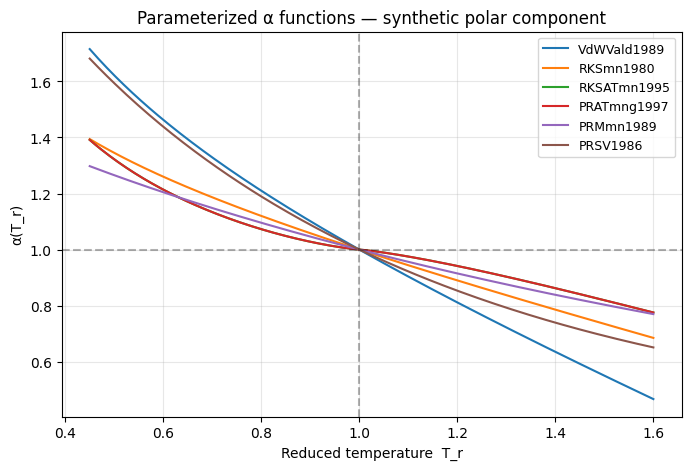

In [5]:
param_variants = [
    CubicEos.VdWVald1989, CubicEos.RKSmn1980, CubicEos.RKSATmn1995,
    CubicEos.PRATmng1997, CubicEos.PRMmn1989, CubicEos.PRSV1986,
]

fig, ax = plt.subplots(figsize=(8, 5))
for i, eos in enumerate(param_variants):
    alphas = [eos_alpha_ex(eos, float(tr), **POLAR) for tr in trs]
    ax.plot(trs, alphas, label=str(eos).split('.')[-1], color=plt.get_cmap('tab10')(i))

ax.axvline(1.0, color='k', alpha=0.3, ls='--')
ax.axhline(1.0, color='k', alpha=0.3, ls='--')
ax.set_xlabel('Reduced temperature  T_r')
ax.set_ylabel('α(T_r)')
ax.set_title('Parameterized α functions — synthetic polar component')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 3. The PRSV K₁ knob

PRSV (Stryjek-Vera, 1986) is the one variant here with a free **component-specific** α parameter, K₁. Its κ is

$$\kappa = \kappa_0(\omega) + K_1\,(1 + \sqrt{T_r})\,(0.7 - T_r),\qquad \alpha = [1 + \kappa(1 - \sqrt{T_r})]^2.$$

K₁ vanishes at T_r = 0.7 (by design — that anchor point keeps the fit honest) and tilts α elsewhere. Setting K₁ = 0 recovers the plain κ₀(ω) form, so K₁ is a pure *correction* fitted to low-temperature vapor-pressure data (notably for water and alcohols). Below we sweep K₁ for a water-like fluid.

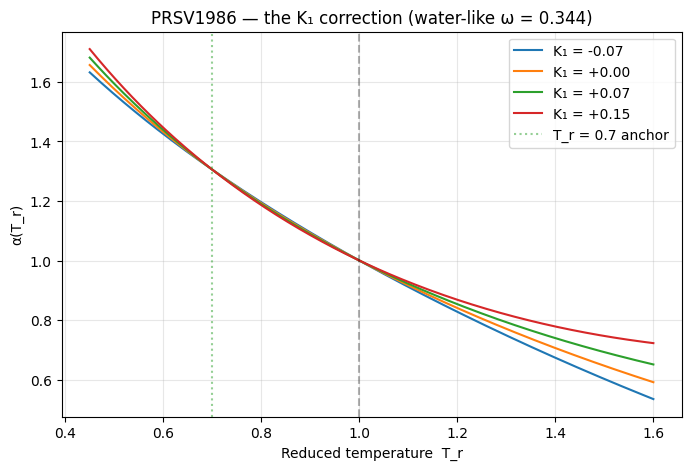

All K₁ curves coincide at T_r = 0.7 (the PRSV anchor) ✓


In [6]:
OMEGA_W = 0.344  # water-like
fig, ax = plt.subplots(figsize=(8, 5))
for k1 in [-0.07, 0.0, 0.07, 0.15]:
    alphas = [eos_alpha_ex(CubicEos.PRSV1986, float(tr), OMEGA_W, prsv_k1=k1) for tr in trs]
    ax.plot(trs, alphas, label=f'K₁ = {k1:+.2f}')

ax.axvline(0.7, color='tab:green', alpha=0.5, ls=':', label='T_r = 0.7 anchor')
ax.axvline(1.0, color='k', alpha=0.3, ls='--')
ax.set_xlabel('Reduced temperature  T_r')
ax.set_ylabel('α(T_r)')
ax.set_title('PRSV1986 — the K₁ correction (water-like ω = 0.344)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# All K₁ curves must coincide at the T_r = 0.7 anchor.
vals = [eos_alpha_ex(CubicEos.PRSV1986, 0.7, OMEGA_W, prsv_k1=k1)
        for k1 in (-0.07, 0.0, 0.07, 0.15)]
assert max(vals) - min(vals) < 1e-12, vals
print('All K₁ curves coincide at T_r = 0.7 (the PRSV anchor) ✓')

## 4. Analytical dα/dT_r vs. a central-difference oracle

Per CLAUDE.md *Algorithm Choices*, every α ships an **analytical** derivative — numerical differentiation exists only as a test oracle. Here we check the analytical `eos_d_alpha_d_tr_ex` against a central difference for all twelve new variants, away from the T_r = 1 corner (the ATmn |1 − T_r|^(g−1) term is only C¹ there).

In [7]:
h = 1e-6
new_variants = [
    CubicEos.Berth1899, CubicEos.VdWAda1984, CubicEos.RKSGD1978,
    CubicEos.RKSL1997, CubicEos.RP1978, CubicEos.PRL1997,
    CubicEos.VdWVald1989, CubicEos.RKSmn1980, CubicEos.RKSATmn1995,
    CubicEos.PRATmng1997, CubicEos.PRMmn1989, CubicEos.PRSV1986,
]
worst = 0.0
for eos in new_variants:
    for tr in (0.55, 0.7, 0.85, 1.1, 1.4):
        ana = eos_d_alpha_d_tr_ex(eos, tr, **POLAR)
        num = (eos_alpha_ex(eos, tr + h, **POLAR)
               - eos_alpha_ex(eos, tr - h, **POLAR)) / (2 * h)
        rel = abs(ana - num) if abs(ana) < 1e-8 else abs((ana - num) / ana)
        worst = max(worst, rel)
        assert rel < 1e-5, f'{eos} Tr={tr}: ana={ana} num={num} rel={rel}'
print(f'Analytical dα/dT_r matches the oracle for all 12 variants '
      f'(worst relative error {worst:.2e}) ✓')

Analytical dα/dT_r matches the oracle for all 12 variants (worst relative error 2.51e-10) ✓


## 5. Still deferred: the OL family (M7.4)

`VdWOL1998`, `RKOL1998`, and `PROL1998` use the form `α = T_r·(1 + Σ h_k·…)` where the `h_k` sum depends on the component's **reduced saturation pressure** (`SumHk`, `clsQbicsPure.cls:268`). That makes α a function of the saturation correlation, not of T_r alone — so the OL family lands with the M7.4 saturation work, not here. Calling it today panics with an explicit `M7.4 deferred` marker:

In [8]:
for eos in (CubicEos.VdWOL1998, CubicEos.RKOL1998, CubicEos.PROL1998):
    try:
        eos_alpha(eos, 0.85, 0.252)
        print(f'{eos}: ERROR — expected a panic')
    except BaseException as exc:
        marker = 'M7.4 deferred' in str(exc)
        print(f'{str(eos).split(".")[-1]:<10} → {type(exc).__name__} '
              f'(M7.4 marker present: {marker})')

VdWOL1998  → PanicException (M7.4 marker present: True)
RKOL1998   → PanicException (M7.4 marker present: True)
PROL1998   → PanicException (M7.4 marker present: True)



thread '<unnamed>' (5266197) panicked at engine/src/eos.rs:420:13:
not implemented: M7.4 deferred: OL-family α(VdWOL1998) depends on reduced saturation pressure (SumHk, legacy/vb6/clsQbicsPure.cls:268) — lands with the M7.4 saturation layer
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace

thread '<unnamed>' (5266197) panicked at engine/src/eos.rs:420:13:
not implemented: M7.4 deferred: OL-family α(RKOL1998) depends on reduced saturation pressure (SumHk, legacy/vb6/clsQbicsPure.cls:268) — lands with the M7.4 saturation layer

thread '<unnamed>' (5266197) panicked at engine/src/eos.rs:420:13:
not implemented: M7.4 deferred: OL-family α(PROL1998) depends on reduced saturation pressure (SumHk, legacy/vb6/clsQbicsPure.cls:268) — lands with the M7.4 saturation layer


## Exercises

Two exercises exercising the new α bindings end-to-end. Solutions are in collapsible `<details>` blocks.

### Exercise 1 — Which α decays fastest below T_c?

For n-pentane (ω = 0.252), compute α at T_r = 0.6 for the four Soave-shaped variants `RKS1972`, `RKSGD1978`, `RKSL1997`, and `RP1978`. Rank them from smallest to largest α. (Smaller α at low T_r ⇒ a *weaker* attractive term there.)

In [9]:
# TODO: build {name: α(0.6)} for the four variants and sort it.
OMEGA = 0.252
# ...


<details>
<summary>Solution</summary>

```python
variants = {
    'RKS1972': CubicEos.RKS1972, 'RKSGD1978': CubicEos.RKSGD1978,
    'RKSL1997': CubicEos.RKSL1997, 'RP1978': CubicEos.RP1978,
}
vals = {name: eos_alpha(eos, 0.6, OMEGA) for name, eos in variants.items()}
for name, a in sorted(vals.items(), key=lambda kv: kv[1]):
    print(f'{name:<10} α(0.6) = {a:.5f}')
```

They land within ~1% of each other — the m(ω) correlations were all fit to similar vapor-pressure data, so they mostly agree for a non-polar alkane. The differences matter far more for polar or associating fluids.
</details>

### Exercise 2 — Fit-free check of the PRSV anchor

Show numerically that for **any** K₁, PRSV's α at T_r = 0.7 equals the K₁ = 0 value. Pick a fluid (say ω = 0.344), evaluate α at T_r = 0.7 for K₁ ∈ {−0.1, 0, 0.1, 0.25}, and assert they are all equal to within 1e-12.

In [10]:
# TODO: evaluate eos_alpha_ex(CubicEos.PRSV1986, 0.7, 0.344, prsv_k1=k1)
# for several k1 and assert they coincide.
# ...


<details>
<summary>Solution</summary>

```python
vals = [eos_alpha_ex(CubicEos.PRSV1986, 0.7, 0.344, prsv_k1=k1)
        for k1 in (-0.1, 0.0, 0.1, 0.25)]
assert max(vals) - min(vals) < 1e-12
print(f'α(T_r=0.7) = {vals[0]:.6f} for every K₁ — the (0.7 − T_r) factor\n'
      f'zeroes the K₁ term exactly at the anchor.')
```

This is why K₁ can be fit to low-temperature data without disturbing the corresponding-states behavior near T_r = 0.7.
</details>

## References

- **Research paper, Chapter II §2.3** — cubic EOS and the Abbott family form. [`docs/en/research-paper/chapter-2-vle-theory.md`](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md)
- **MODERNIZATION_PLAN.md — Phase 7** — the α-function port plan and the M7.1 / M7.2 / M7.3 / M7.4 split. [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/MODERNIZATION_PLAN.md)
- **Reference (5): Abbott** — the generalized cubic-EOS family form.
- **Source:** all twelve α functions ported from `legacy/vb6/clsQbicsPure.cls:1719` (`Friend Function Alpha`); the PRSV κ₀(ω) polynomial and the Mathias-Naumann exponential forms are transcribed verbatim with hand-derived analytical derivatives.
- **Companion notebooks:** [`02_pure_component.ipynb`](02_pure_component.ipynb) (M7.1 core), [`02c_three_param_eos.ipynb`](02c_three_param_eos.ipynb) (M7.3 three-parameter EOS), and [`02d_advanced_saturation.ipynb`](02d_advanced_saturation.ipynb) (M7.4 — where the OL family lands).